In [1]:
import numpy as np
import pandas as pd

C:\Users\ayush\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df_lok = pd.read_csv("https://samatrix-data.s3.ap-south-1.amazonaws.com/Statistics-Project/ind-lok-sabha.csv")
df_vidhan = pd.read_csv("https://samatrix-data.s3.ap-south-1.amazonaws.com/Statistics-Project/ind-vidhan-sabha.csv")


In [3]:
df_vidhan.head()

,st_name,year,ac_no,ac_name,ac_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Manabala Ramarao,M,Independent,IND,813.0,83247
1,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Appadu Sahu,M,Independent,IND,1743.0,83247
2,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Uppada Rangababu,M,Indian National Congress,INC,4427.0,83247
3,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Kalla Balarama Swamy,M,Indian National Congress (I),INC(I),19805.0,83247
4,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Bendalam Venkatesam Sarma,M,Janata Party,JNP,34251.0,83247


In [4]:
df_vidhan.shape

(327294, 11)

In [5]:
df_vidhan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327294 entries, 0 to 327293
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   st_name     327294 non-null  object 
 1   year        327294 non-null  float64
 2   ac_no       327294 non-null  int64  
 3   ac_name     311211 non-null  object 
 4   ac_type     327294 non-null  object 
 5   cand_name   327294 non-null  object 
 6   cand_sex    321992 non-null  object 
 7   partyname   327294 non-null  object 
 8   partyabbre  324588 non-null  object 
 9   totvotpoll  327287 non-null  float64
 10  electors    327294 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 27.5+ MB


In [6]:
df_vidhan.isnull().sum()

st_name           0
year              0
ac_no             0
ac_name       16083
ac_type           0
cand_name         0
cand_sex       5302
partyname         0
partyabbre     2706
totvotpoll        7
electors          0
dtype: int64

In [7]:
valid_pairs = df_vidhan.dropna(subset=['partyname','partyabbre'])
party_abbrev_map = (
    valid_pairs.groupby('partyname')['partyabbre']
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)

df_vidhan['partyabbre'] = df_vidhan.apply(
    lambda row: party_abbrev_map.get(row['partyname'], row['partyabbre']),
    axis=1
)

df_vidhan['partyabbre'] = df_vidhan['partyabbre'].fillna('IND')

In [8]:
df_vidhan['partyabbre'].value_counts().head(10)

partyabbre
IND    163687
INC     27363
BJP     20053
BSP     13076
JNP      6779
SP       5137
JD       4723
CPI      4045
CPM      3977
DDP      3620
Name: count, dtype: int64

In [9]:
df_vidhan['partyabbre'] = df_vidhan['partyabbre'].replace({
    'INC(I)': 'INC'
})

In [10]:
df_vidhan['partyabbre'].value_counts().head(10).sort_index()

partyabbre
BJP     20053
BSP     13076
CPI      4045
CPM      3977
DDP      3620
INC     30391
IND    163687
JD       4723
JNP      6779
SP       5137
Name: count, dtype: int64

In [11]:
# Convert 'year' to integer
df_vidhan['year'] = df_vidhan['year'].astype(int)

# Fill missing 'cand_sex' with 'U'
df_vidhan['cand_sex'] = df_vidhan['cand_sex'].fillna('U')

# Drop rows with missing 'totvotpoll'
df_vidhan = df_vidhan.dropna(subset=['totvotpoll'])

In [12]:
# Step 1: Build mapping of (st_name, ac_no) to most common ac_name
ac_name_map = (
    df_vidhan[~df_vidhan['ac_name'].isna()]
    .groupby(['st_name', 'ac_no'])['ac_name']
    .agg(lambda x: x.value_counts().idxmax())
)

# Step 2: Fill missing ac_name using that mapping
def fill_ac_name(row):
    if pd.isna(row['ac_name']):
        return ac_name_map.get((row['st_name'], row['ac_no']), np.nan)
    return row['ac_name']

df_vidhan['ac_name'] = df_vidhan.apply(fill_ac_name, axis=1)

# Step 3: Check remaining missing values
print("Missing ac_name after fill:", df_vidhan['ac_name'].isna().sum())

Missing ac_name after fill: 0


In [13]:
df_vidhan.isnull().sum()

st_name       0
year          0
ac_no         0
ac_name       0
ac_type       0
cand_name     0
cand_sex      0
partyname     0
partyabbre    0
totvotpoll    0
electors      0
dtype: int64

In [14]:
df_lok.head()

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


In [15]:
df_lok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73081 entries, 0 to 73080
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   st_name     73081 non-null  object
 1   year        73081 non-null  int64 
 2   pc_no       73081 non-null  int64 
 3   pc_name     73081 non-null  object
 4   pc_type     65011 non-null  object
 5   cand_name   73081 non-null  object
 6   cand_sex    72539 non-null  object
 7   partyname   73081 non-null  object
 8   partyabbre  73081 non-null  object
 9   totvotpoll  73081 non-null  int64 
 10  electors    73081 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 6.1+ MB


In [16]:
 df_lok.shape

(73081, 11)

In [17]:
df_lok.isnull().sum()

st_name          0
year             0
pc_no            0
pc_name          0
pc_type       8070
cand_name        0
cand_sex       542
partyname        0
partyabbre       0
totvotpoll       0
electors         0
dtype: int64

In [18]:
df_lok['cand_sex'] = df_lok['cand_sex'].fillna('U')
df_lok['pc_type'] = df_lok['pc_type'].fillna('Unknown')
df_lok.isnull().sum()

st_name       0
year          0
pc_no         0
pc_name       0
pc_type       0
cand_name     0
cand_sex      0
partyname     0
partyabbre    0
totvotpoll    0
electors      0
dtype: int64

In [19]:
df_lok['partyabbre'].value_counts().head(50)

partyabbre
IND           41127
INC            4800
BJP            3350
BSP            2624
SP             1057
JD              943
CPM             770
DDP             716
JNP             675
CPI             608
JP              551
NOTA            543
INC(I)          492
SHS             462
AAAP            432
BLD             405
AIIC(T)         321
TDP             301
JNP(S)          294
RJD             291
AD              286
CPI(ML)(L)      286
JD(U)           281
NCP             268
DMK             253
AJBP            253
LKD             253
BMUP            233
AITC            228
RPI             216
INC(U)          212
JD(S)           208
SAP             198
JMM             176
ADMK            158
JNP (JP)        155
GGP             123
MUL             120
LKD (B)         116
PMK             116
LJP             113
RPI(A)          111
PPOI            110
ABHM             95
AMB              94
IJP              93
FBL              93
CPI(ML)          88
SAD              87
BBM      

In [20]:
df_lok['partyabbre'].value_counts().head(50).sort_index()

partyabbre
AAAP            432
ABHM             95
AD              286
ADMK            158
AIIC(T)         321
AITC            228
AJBP            253
AMB              94
BBM              86
BJP            3350
BLD             405
BMUP            233
BSP            2624
CPI             608
CPI(ML)          88
CPI(ML)(L)      286
CPM             770
DDP             716
DMK             253
FBL              93
GGP             123
IJP              93
INC            4800
INC(I)          492
INC(U)          212
IND           41127
JD              943
JD(S)           208
JD(U)           281
JMM             176
JNP             675
JNP (JP)        155
JNP(S)          294
JP              551
LJP             113
LKD             253
LKD (B)         116
MUL             120
NCP             268
NOTA            543
PMK             116
PPOI            110
RJD             291
RPI             216
RPI(A)          111
SAD              87
SAP             198
SHS             462
SP             1057
TDP      

In [21]:
df_lok['partyabbre'] = df_lok['partyabbre'].replace({
    'INC(I)' : 'INC' 
})

In [22]:
print("Unique Counts:")
print("unique States:",df_vidhan['st_name'].nunique())
print("Years Covered:",df_vidhan['year'].nunique())
print("Unique Constituencies:", df_vidhan['ac_no'].nunique())
print("Unique Candidate:", df_vidhan['cand_name'].nunique())
print("Unique Parties:", df_vidhan['partyabbre'].nunique())


Unique Counts:
unique States: 30
Years Covered: 36
Unique Constituencies: 425
Unique Candidate: 220529
Unique Parties: 1248


  Gender   Count
0      M  307091
1      F   14883
2      U    5302
3      O      11


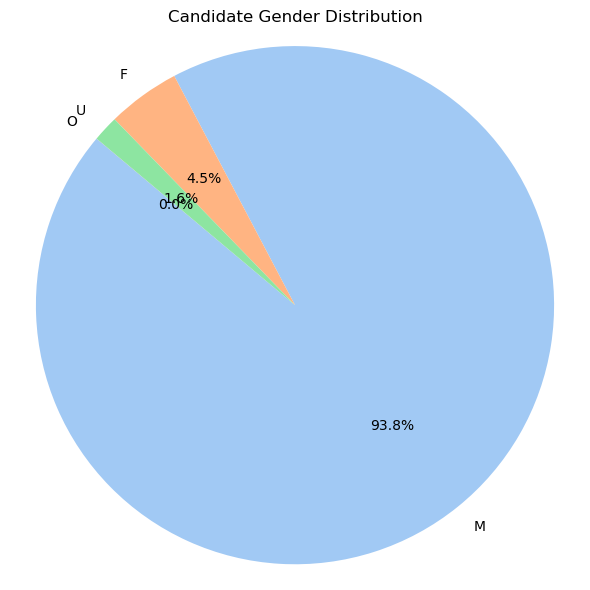

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

gender_counts = df_vidhan['cand_sex'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']
print(gender_counts)

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts['Count'],
    labels=gender_counts['Gender'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette( 'pastel')
)

plt.title('Candidate Gender Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

    Year  Avg_Candidates_Per_Seat
0   1977                36.708235
1   1978                19.384354
2   1979                12.312500
3   1980                39.305882
4   1982                11.676871
5   1983                15.200680
6   1984                 7.470085
7   1985                57.840000
8   1987                16.122449
9   1989                30.978824
10  1990                65.114198
11  1991                40.286396
12  1992                 4.931624
13  1993                41.716981
14  1994                20.061224
15  1995                53.206790
16  1996                39.681604
17  1997                 5.905983
18  1998                20.215625
19  1999                19.472789
20  2000                17.783951
21  2001                17.428571
22  2002                20.193548
23  2003                25.743478
24  2004                24.972789
25  2005                29.246914
26  2006                20.928571
27  2007                24.866005
28  2008      

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


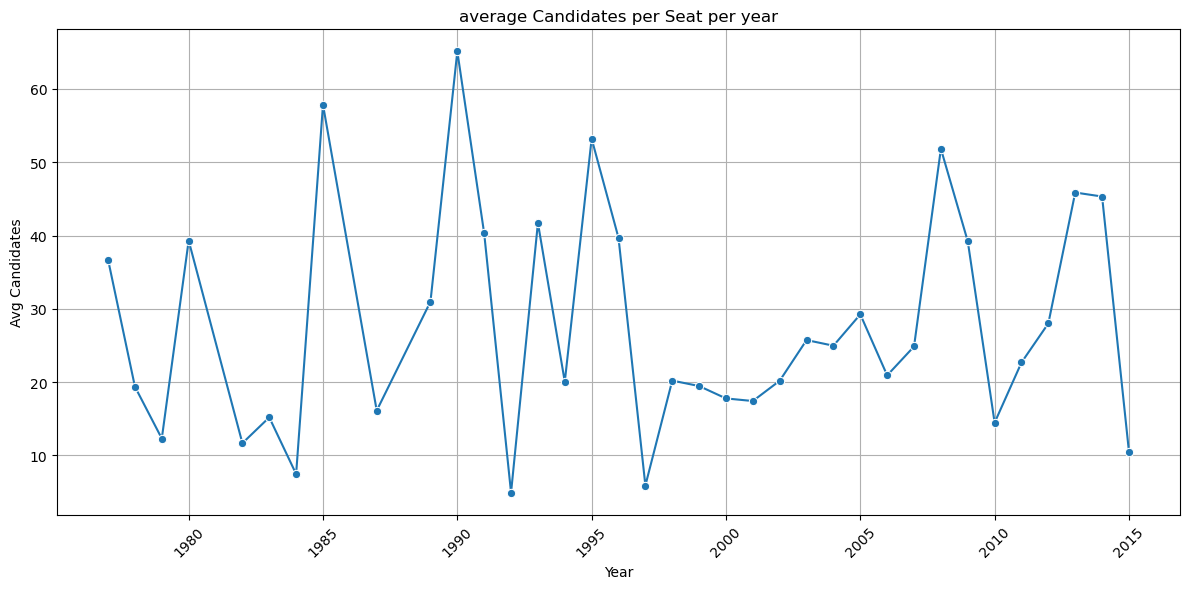

In [24]:
candidates_per_seat = df_vidhan.groupby(['year', 'ac_no'])['cand_name'].nunique()
avg_candidates_per_seat = candidates_per_seat.groupby('year').mean().reset_index()
avg_candidates_per_seat.columns = ['Year', 'Avg_Candidates_Per_Seat']
print(avg_candidates_per_seat)

plt.figure(figsize=(12,6))
sns.lineplot(data=avg_candidates_per_seat, x='Year', y='Avg_Candidates_Per_Seat', marker='o')

plt.title('average Candidates per Seat per year')
plt.ylabel('Avg Candidates')
plt.xlabel('Year')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    year  totvotpoll   electors  voter_turnout_percent
0   1977  59107891.0  226166275              26.134706
1   1978  27708972.0   85753182              32.312471
2   1979     94133.0     359101              26.213517
3   1980  64915667.0  258603200              25.102422
4   1982  20187665.0   52422974              38.509194
5   1983  21296499.0   66063231              32.236539
6   1984  12232502.0   31523449              38.804453
7   1985  86255868.0  312198536              27.628531
8   1987  25323833.0   63872512              39.647467
9   1989  49919785.0  186678633              26.741028
10  1990  57125442.0  213268107              26.785741
11  1991  57289242.0  203190207              28.194883
12  1992   1416408.0   13171851              10.753295
13  1993  41990796.0  167611922              25.052392
14  1994  25693484.0   75778249              33.906146
15  1995  46243622.0  164492560              28.112896
16  1996  71148520.0  237706787              29.931211
17  1997  

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


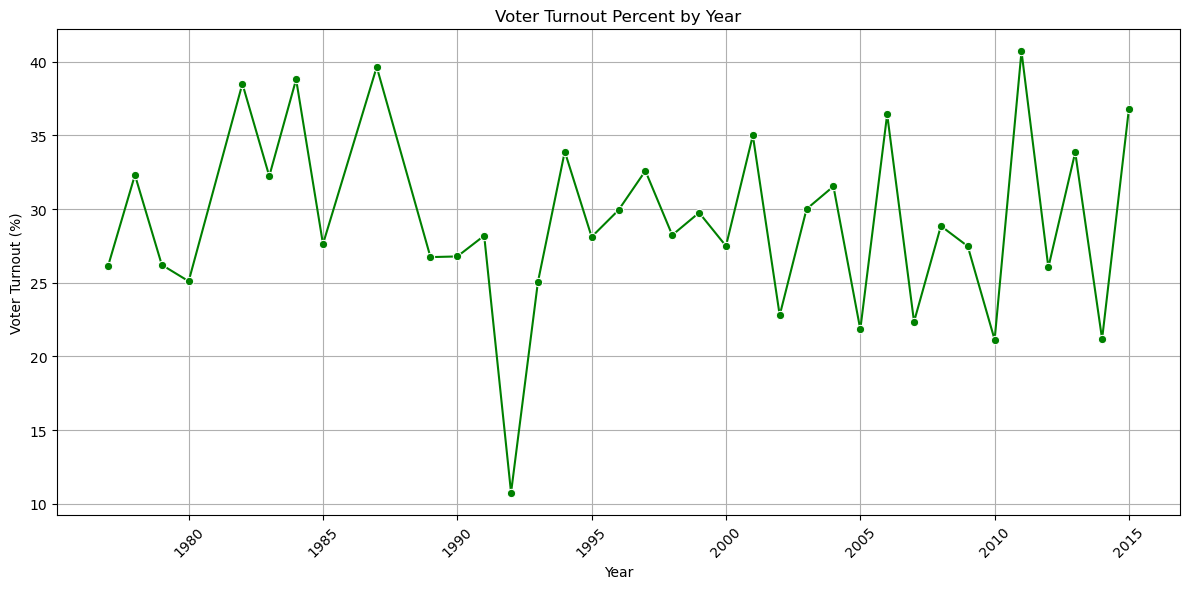

In [25]:
constituency_turnout = (
    df_vidhan.groupby(['year', 'st_name', 'ac_no'])[['totvotpoll', 'electors']]
    .agg({'totvotpoll': 'max', 'electors': 'max'})
    .reset_index()
)

yearly_turnout = constituency_turnout.groupby('year')[['totvotpoll', 'electors']].sum().reset_index()

yearly_turnout['voter_turnout_percent'] = (yearly_turnout['totvotpoll'] / yearly_turnout['electors']) * 100
print(yearly_turnout)

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_turnout, x='year', y='voter_turnout_percent', marker='o', color='green')
plt.title('Voter Turnout Percent by Year')
plt.xlabel('Year')
plt.ylabel('Voter Turnout (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


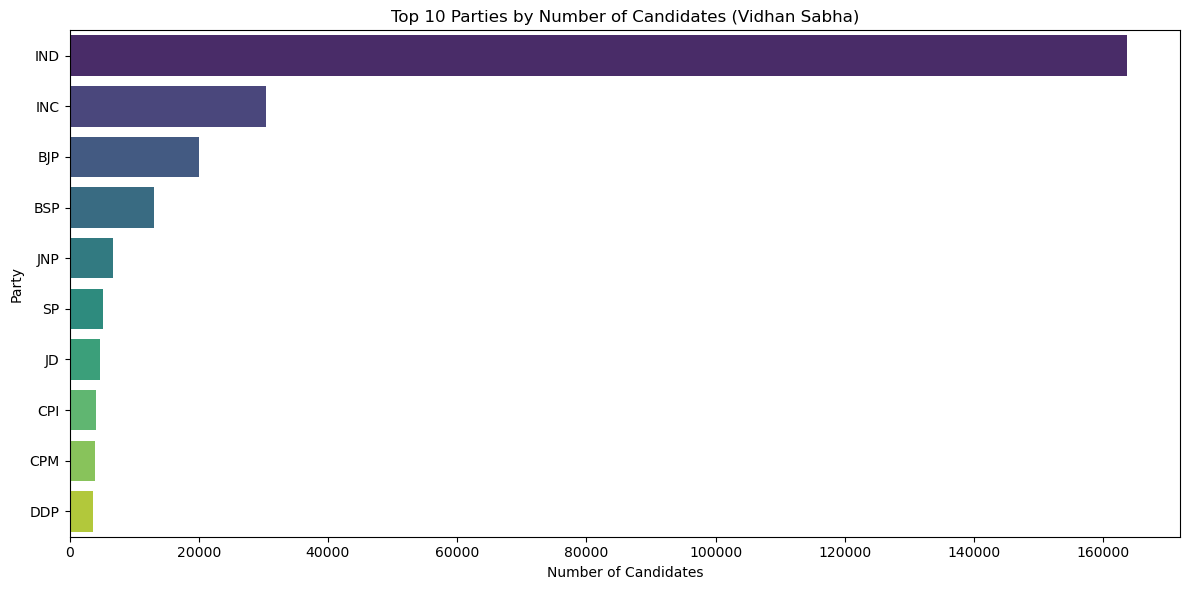

In [26]:
party_counts = df_vidhan['partyabbre'].value_counts().nlargest(10).reset_index()
party_counts.columns = ['Party', 'Candidate_Count']

plt.figure(figsize=(12,6))
sns.barplot(
    data=party_counts,
    x='Candidate_Count',
    y='Party',
    palette='viridis'
)

plt.title('Top 10 Parties by Number of Candidates (Vidhan Sabha)')
plt.xlabel('Number of Candidates')
plt.ylabel('Party')
plt.tight_layout()
plt.show()


In [27]:
# Drop rows with missing 'totvotpoll'
df_valid = df_vidhan.dropna(subset=['totvotpoll'])

# Get winners by selecting candidate with max 'totvotpoll' per seat per year
winners_df = df_valid.loc[df_valid.groupby(['year', 'st_name', 'ac_no'])['totvotpoll'].idxmax()]

# Filter for Gujarat (State) and display selected columns
print(
    winners_df[winners_df['st_name'] == 'Gujarat'][['st_name', 'year', 'ac_name', 'cand_name', 'partyabbre', 'totvotpoll']]
    .sort_values(by='year', ascending=False)
    .head(10)
)


       st_name  year      ac_name                         cand_name  \
84729  Gujarat  2012    Umbergaon          Ramanlal Nanubhai Patkar   
83704  Gujarat  2012  Rajkot East       Rajguru Indranil Sanjaybhai   
83689  Gujarat  2012      Tankara  Kundariya Mohanbhai Kalyanjibhai   
83676  Gujarat  2012        Morbi         Amrutiya Kantilal Shivlal   
83668  Gujarat  2012  Dhrangadhra    Kavadiya Jayantibhai Ramjibhai   
83655  Gujarat  2012      Chotila     Shamjibhai Bhimjibhai Chauhan   
83649  Gujarat  2012      Wadhwan      Doshi Varshaben Narendrabhai   
83636  Gujarat  2012       Limbdi       Kolipatel Somabhai Gandalal   
83623  Gujarat  2012       Dasada        Makwana Punambhai Kalabhai   
83616  Gujarat  2012    Dhandhuka    Kolipatel Laljibhai Chaturbhai   

      partyabbre  totvotpoll  
84729        BJP     69450.0  
83704        INC     60877.0  
83689        BJP     63630.0  
83676        BJP     77386.0  
83668        BJP     87621.0  
83655        BJP     72111.0  
8

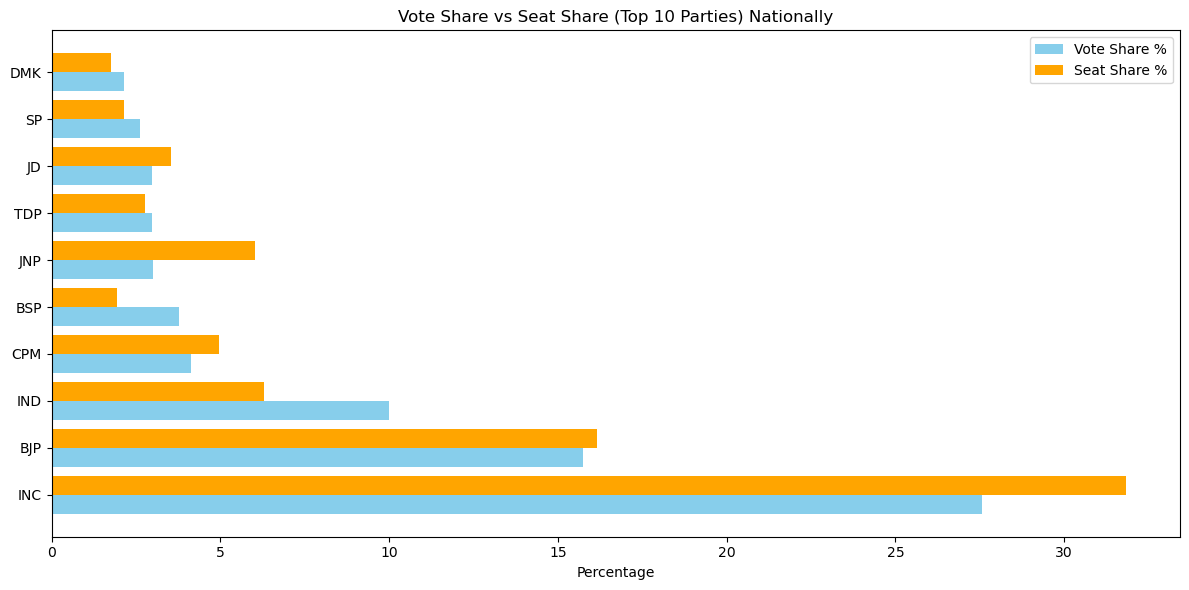

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
# Prepare vote and seat share
party_votes = df_vidhan.groupby('partyabbre')['totvotpoll'].sum()
total_votes = party_votes.sum()
party_vote_share = (party_votes / total_votes * 100).reset_index()
party_vote_share.columns = ['Party', 'Vote_Share']

party_seats = winners_df['partyabbre'].value_counts(normalize=True) * 100
party_seats_share = party_seats.reset_index()
party_seats_share.columns = ['Party', 'Seat_Share']

# Merge both shares
share_df = pd.merge(party_vote_share, party_seats_share, on='Party')

# Get top 10 parties by vote share
top_parties = share_df.sort_values('Vote_Share', ascending=False).head(10)

# Plotting
plt.figure(figsize=(12, 6))
bar_width = 0.4
x = range(len(top_parties))

plt.barh(x, top_parties['Vote_Share'], height=bar_width, label='Vote Share %', color='skyblue')
plt.barh([p + bar_width for p in x], top_parties['Seat_Share'], height=bar_width, label='Seat Share %', color='orange')

plt.yticks([p + bar_width / 2 for p in x], top_parties['Party'])
plt.xlabel('Percentage')
plt.title('Vote Share vs Seat Share (Top 10 Parties) Nationally')
plt.legend()
plt.tight_layout()
plt.show()


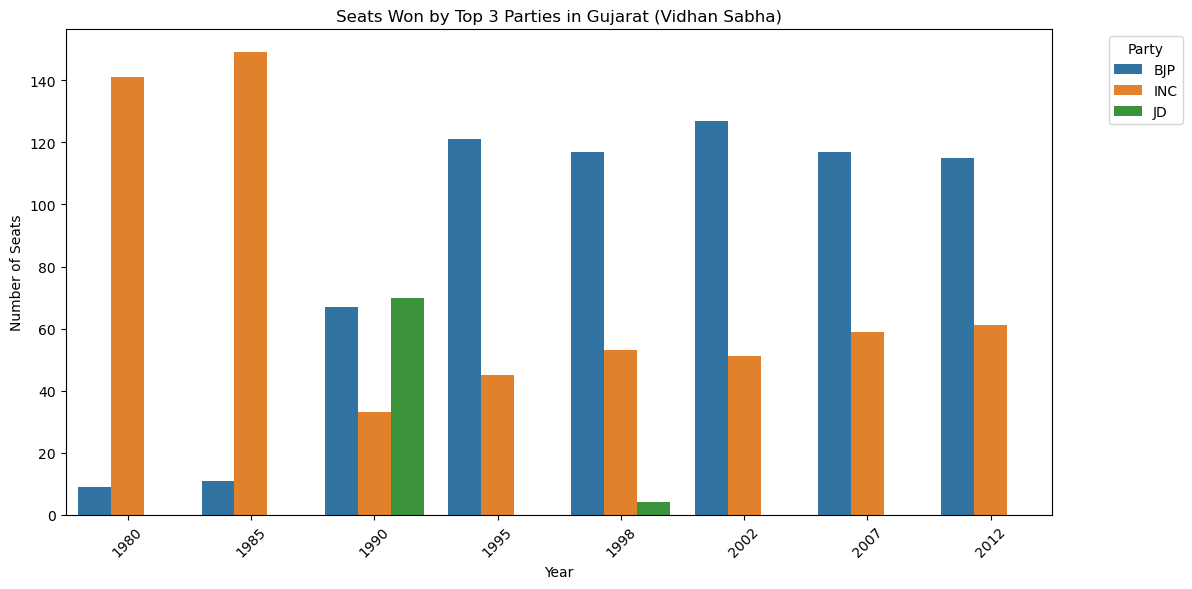

In [29]:
winners_gujarat = winners_df[winners_df['st_name'] == 'Gujarat'].copy()

top_3_parties = winners_gujarat['partyabbre'].value_counts().nlargest(3).index.tolist()

winners_gujarat_top3 = winners_gujarat[winners_gujarat['partyabbre'].isin(top_3_parties)]

party_seats_year =(
    winners_gujarat_top3.groupby(['year','partyabbre']).size()
    .reset_index(name='seats')
)

plt.figure(figsize=(12,6))
sns.barplot(data=party_seats_year, x='year', y='seats', hue='partyabbre')
plt.title('Seats Won by Top 3 Parties in Gujarat (Vidhan Sabha)')
plt.ylabel('Number of Seats')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.legend(title='Party', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

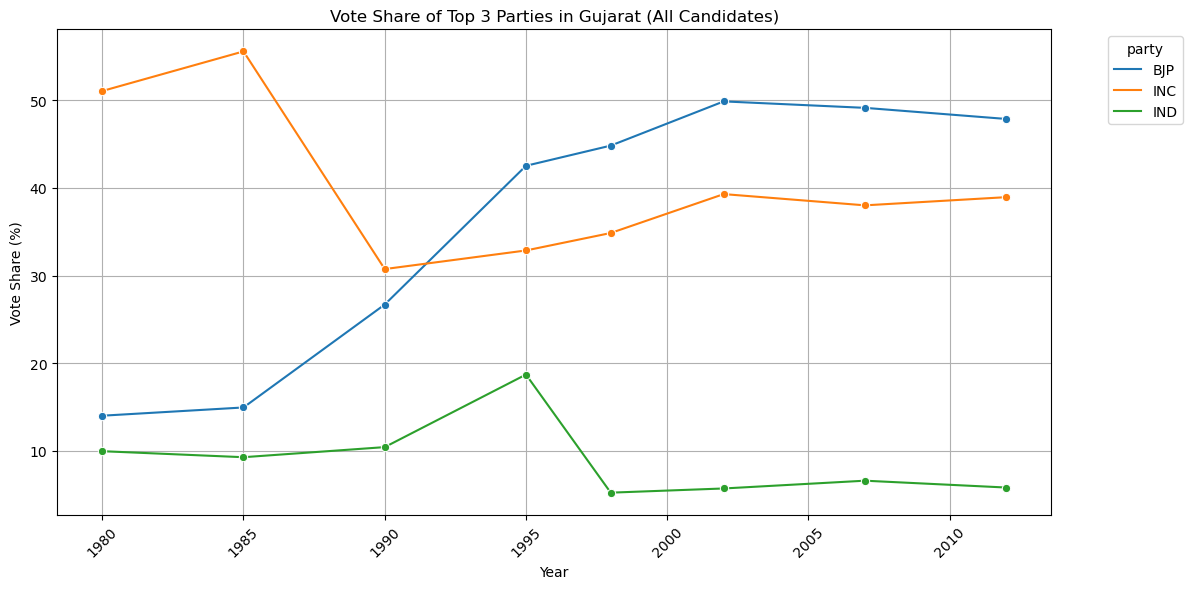

In [30]:
gujarat_df = df_vidhan[df_vidhan['st_name'] == 'Gujarat'].copy()

party_votes = (
    gujarat_df.groupby(['year', 'partyabbre'])['totvotpoll']
    .sum()
    .reset_index()
)

total_votes_per_year = (
    gujarat_df.groupby('year')['totvotpoll']
    .sum()
    .reset_index()
    .rename(columns={'totvotpoll' : 'total_votes'})
)

party_vote_share = pd.merge(party_votes, total_votes_per_year, on='year')
party_vote_share['vote_share_percent'] = (party_vote_share['totvotpoll'] / party_vote_share['total_votes'])*100

top_parties = (
    gujarat_df.groupby('partyabbre')['totvotpoll']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)

top_vote_share = party_vote_share[party_vote_share['partyabbre'].isin(top_parties)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_vote_share,
    x='year',
    y='vote_share_percent',
    hue='partyabbre',
    marker='o'
)

plt.title('Vote Share of Top 3 Parties in Gujarat (All Candidates)')
plt.xlabel('Year')
plt.ylabel('Vote Share (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='party', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


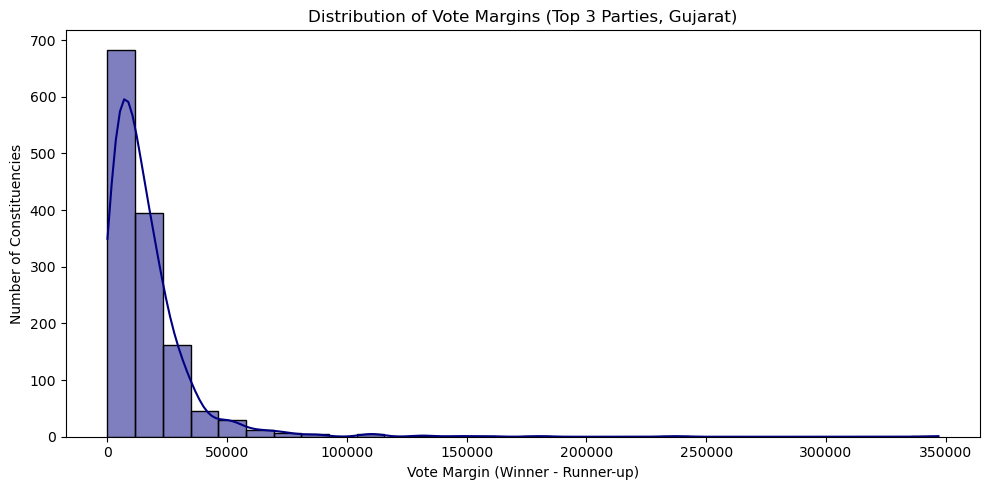

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

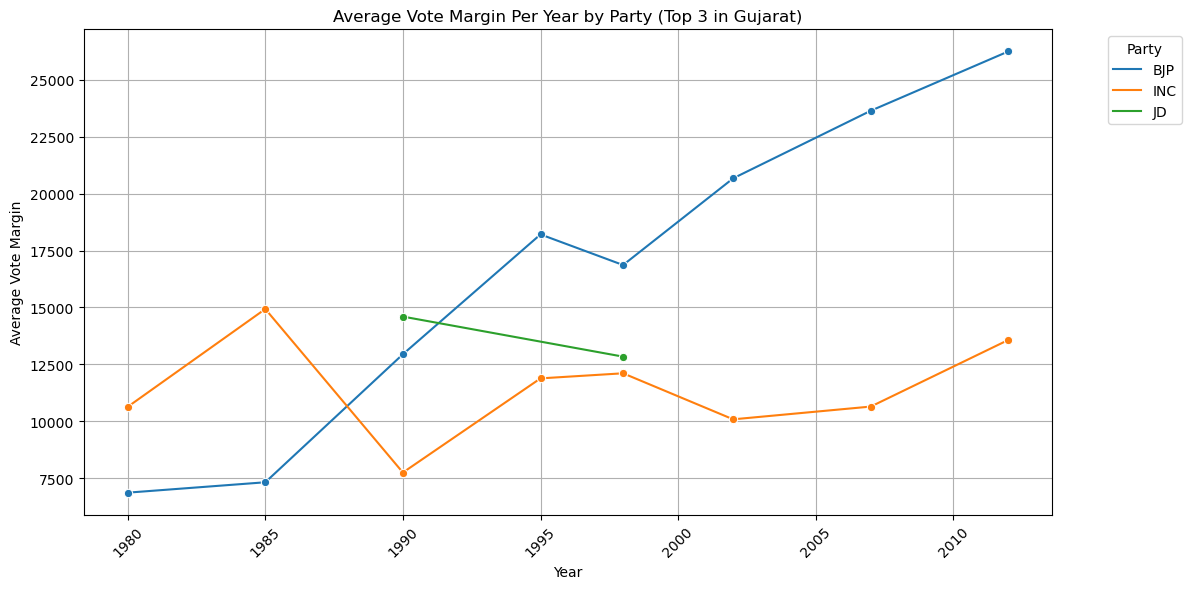

Outliers Years in Vote Margin Trends (Top 3 Parties,Gujarat):
    year party   vote_margin
16  2012   BJP  26236.504348
14  2007   BJP  23632.948718
12  2002   BJP  20666.952756
7   1995   BJP  18206.305785
9   1998   BJP  16862.564103
1   1980   INC  10640.100000
13  2002   INC  10091.764706
5   1990   INC   7757.242424
2   1985   BJP   7329.909091
0   1980   BJP   6874.333333


In [31]:
df_vidhan['vote_share_percent'] = (df_vidhan['totvotpoll'] / df_vidhan['electors'])*100

gujarat_df = df_vidhan[df_vidhan['st_name'] == 'Gujarat'].copy()

gujarat_df['rank'] = gujarat_df.groupby(['year', 'ac_no'])['totvotpoll'].rank(method='first',ascending=False)

winners = gujarat_df[gujarat_df['rank']==1].copy()
runners_up = gujarat_df[gujarat_df['rank']==2].copy()

merged = pd.merge(
    winners,
    runners_up,
    on=['year','ac_no'],
    suffixes = ('_winner', '_runnerup')
)

merged['vote_margin'] = merged['totvotpoll_winner'] - merged['totvotpoll_runnerup']

top_3_parties = winners['partyabbre'].value_counts().nlargest(3).index.tolist()

merged_top3 = merged[merged['partyabbre_winner'].isin(top_3_parties)].copy()

plt.figure(figsize=(10,5))
sns.histplot(merged_top3['vote_margin'], bins=30, kde=True, color='navy')
plt.title('Distribution of Vote Margins (Top 3 Parties, Gujarat)')
plt.xlabel('Vote Margin (Winner - Runner-up)')
plt.ylabel('Number of Constituencies')
plt.tight_layout()
plt.show()

avg_margin_year_party = (
    merged_top3.groupby(['year','partyabbre_winner'])['vote_margin']
    .mean()
    .reset_index()
    .rename(columns={'partyabbre_winner': 'party'})
)

plt.figure(figsize=(12,6))
#sns.lineplot(data=ave_margin_year_party, x='year', y='vote_margin', hue='party', marker='0')
sns.lineplot(data=avg_margin_year_party, x='year', y='vote_margin', hue='party', marker='o')

plt.title('Average Vote Margin Per Year by Party (Top 3 in Gujarat)')
plt.xlabel('Year')
plt.ylabel('Average Vote Margin')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Party', bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

q1 = avg_margin_year_party['vote_margin'].quantile(0.25)
q3 = avg_margin_year_party['vote_margin'].quantile(0.75)
outliers = avg_margin_year_party[
    (avg_margin_year_party['vote_margin'] < q1) |
    (avg_margin_year_party['vote_margin'] > q3)
]

print("Outliers Years in Vote Margin Trends (Top 3 Parties,Gujarat):")
print(outliers.sort_values(by='vote_margin', ascending=False))

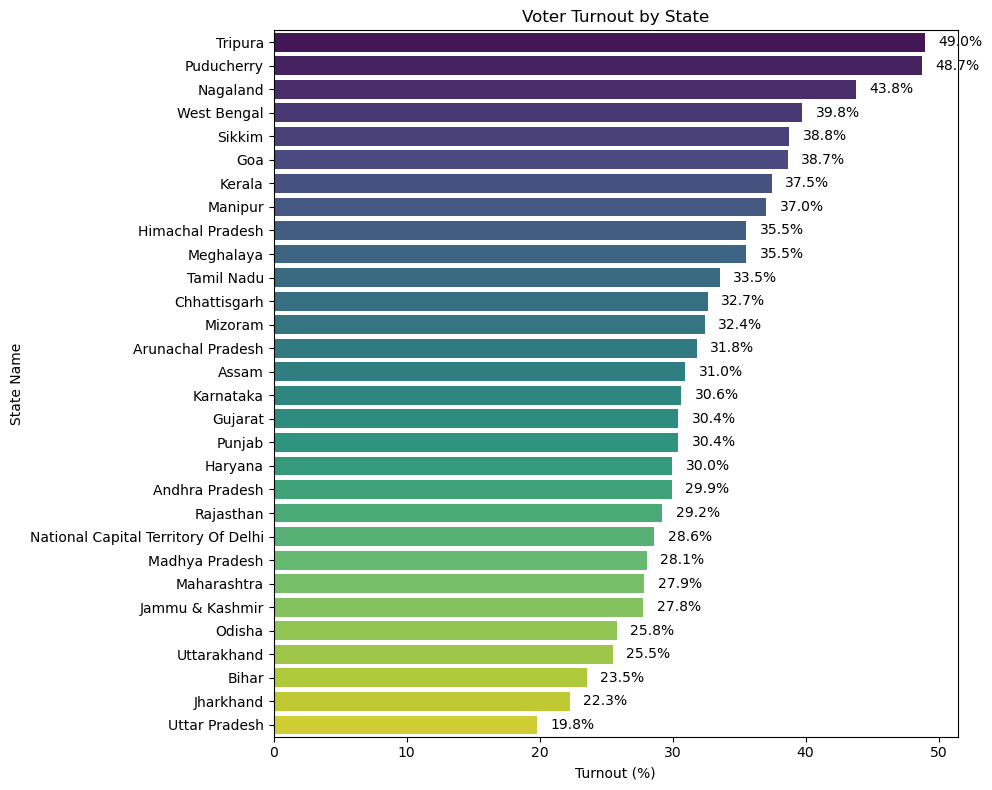

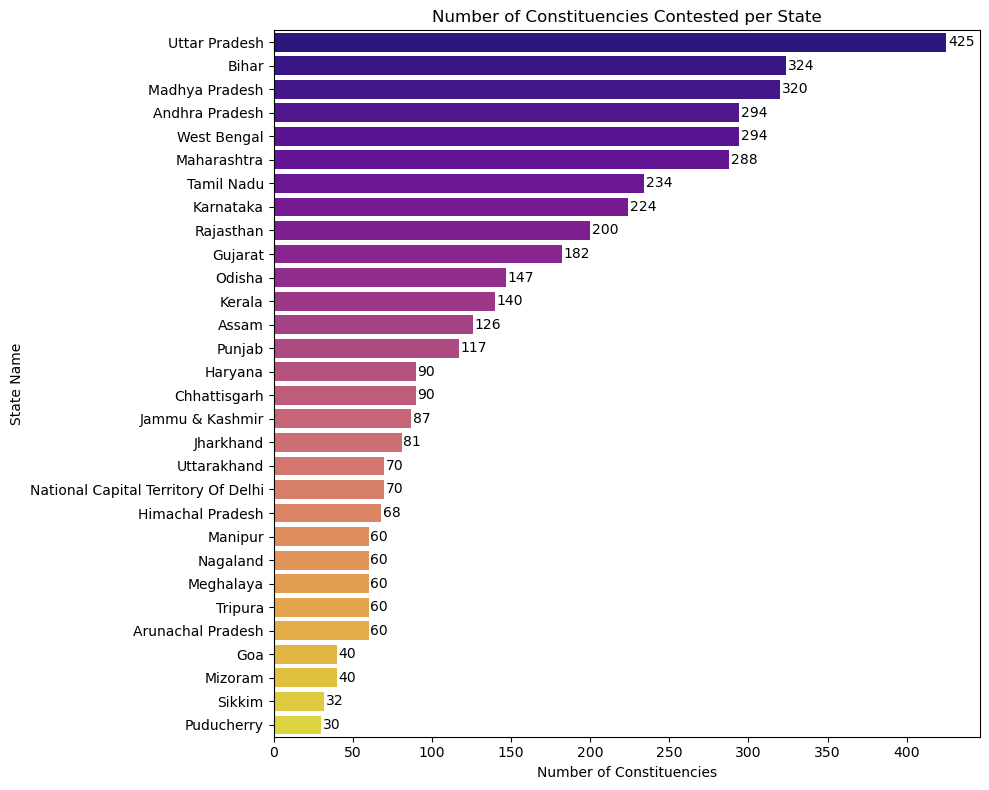

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute turnout as a DataFrame for plotting
state_turnout_df = (
    constituency_turnout.groupby('st_name')[['totvotpoll','electors']]
    .sum()
    .assign(voter_turnout_percent=lambda x: (x['totvotpoll'] / x['electors']) *100)
    .sort_values('voter_turnout_percent', ascending=False)
    .reset_index()
)

state_constituencies_df = (
    df_vidhan.groupby('st_name')['ac_no']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'ac_no': 'num_constituencies'})
)

font_name = 'DejaVu Sans'

# --- First Plot: Voter Turnout ---
plt.figure(figsize=(10,8))
ax1 = sns.barplot(
    data=state_turnout_df,
    x='voter_turnout_percent',
    y='st_name',
    palette='viridis'
)

plt.title('Voter Turnout by State', fontdict={'fontname': font_name})
plt.xlabel('Turnout (%)', fontdict={'fontname': font_name})
plt.ylabel('State Name', fontdict = {'fontname': font_name})
plt.xticks(fontname=font_name)
plt.yticks(fontname=font_name)

for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.1f}%', (p.get_width()+1,p.get_y() +p.get_height()/2),
                 ha='left',va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# --- Second Plot: Constituencies per State ---
plt.figure(figsize=(10,8))
ax2 = sns.barplot(
    data=state_constituencies_df,
    x='num_constituencies',
    y='st_name',
    palette='plasma'
)

plt.title('Number of Constituencies Contested per State', fontdict={'fontname': font_name})
plt.xlabel('Number of Constituencies', fontdict={'fontname': font_name})
plt.ylabel('State Name', fontdict = {'fontname': font_name})
plt.xticks(fontname=font_name)
plt.yticks(fontname=font_name)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width())}', (p.get_width() + 1, p.get_y() + p.get_height()/2),
                 ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


In [33]:
gender_participation = df_lok['cand_sex'].value_counts().reset_index()
gender_participation.columns = ['Gender', 'Number_of_Candidates']

df_lok['rank'] = df_lok.groupby(['year', 'st_name', 'pc_no'])['totvotpoll'].rank(method='first', ascending=False)
winners_lok = df_lok[df_lok['rank'] ==1].copy()

gender_wins = winners_lok['cand_sex'].value_counts().reset_index()
gender_wins.columns = ['Gender','Number_of_Winners']

gender_analysis = pd.merge(
    gender_participation,
    gender_wins,
    on='Gender',
    how='left'
).fillna(0)

gender_analysis['Win_Rate (%)'] = (
    gender_analysis['Number_of_Winners']/gender_analysis['Number_of_Candidates']
) *100

print("\nGender-Based Participation and Performance (Lok Sabha):")
print(gender_analysis.sort_values(by='Number_of_Candidates', ascending=False))


Gender-Based Participation and Performance (Lok Sabha):
  Gender  Number_of_Candidates  Number_of_Winners  Win_Rate (%)
0      M                 68885             5479.0      7.953836
1      F                  3648              455.0     12.472588
2      U                   542                0.0      0.000000
3      O                     6                0.0      0.000000


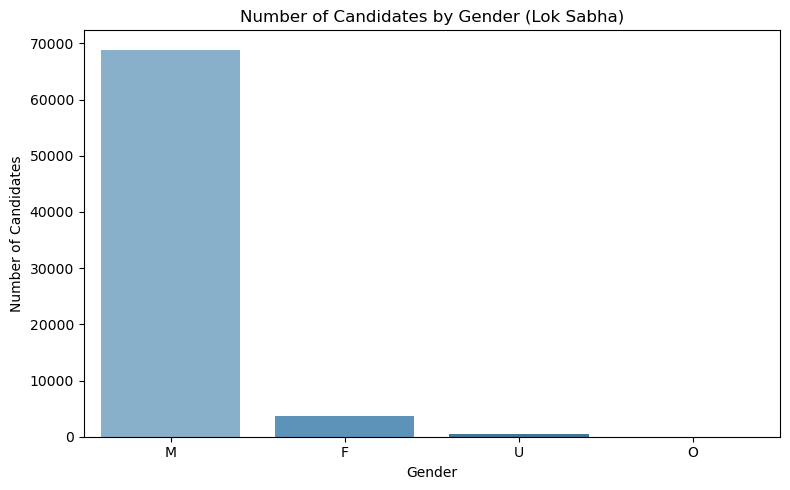

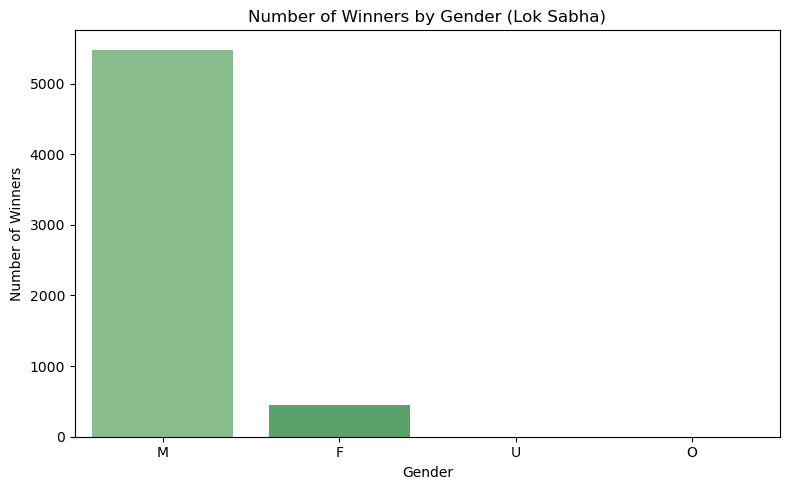

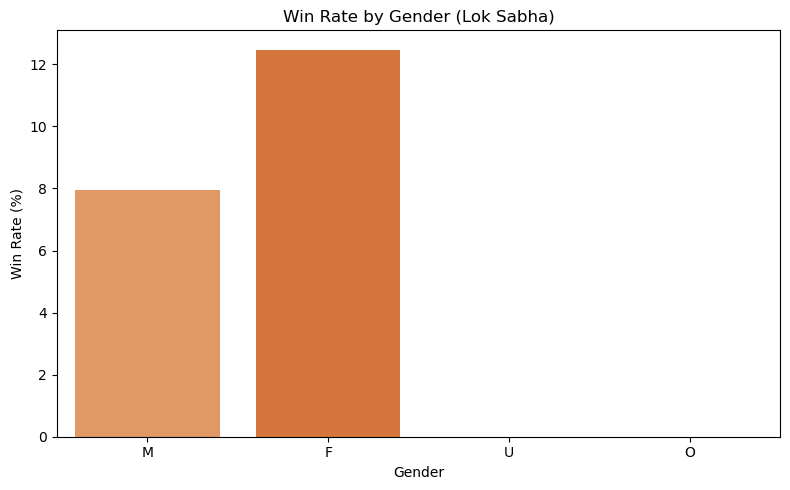

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot 1: Number of Candidates by Gender ---
plt.figure(figsize=(8, 5))
sns.barplot(
    data=gender_analysis,
    x='Gender',
    y='Number_of_Candidates',
    palette='Blues_d'
)

plt.title('Number of Candidates by Gender (Lok Sabha)')
plt.ylabel('Number of Candidates')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

# --- Plot 2: Number of Winners by Gender ---
plt.figure(figsize=(8, 5))
sns.barplot(
    data=gender_analysis,
    x='Gender',
    y='Number_of_Winners',
    palette='Greens_d'
)

plt.title('Number of Winners by Gender (Lok Sabha)')
plt.ylabel('Number of Winners')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

# --- Plot 3: Win Rate (%) by Gender ---
plt.figure(figsize=(8, 5))
sns.barplot(
    data=gender_analysis,
    x='Gender',
    y='Win_Rate (%)',
    palette='Oranges_d'
)

plt.title('Win Rate by Gender (Lok Sabha)')
plt.ylabel('Win Rate (%)')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()


C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

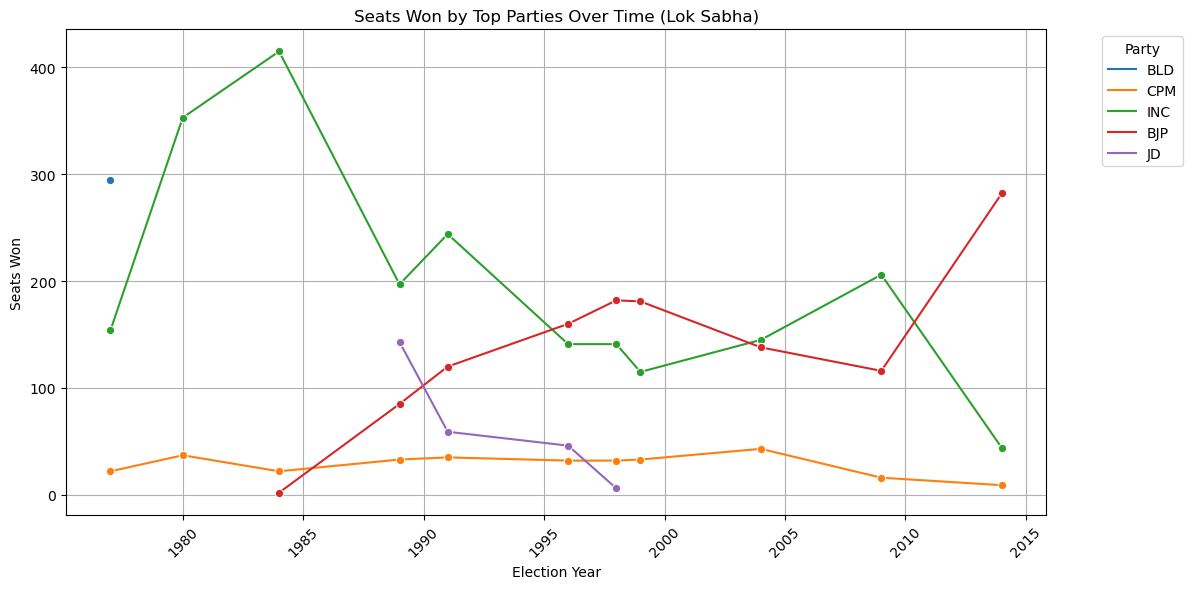

In [35]:
winner_idx = df_lok.groupby(['year', 'st_name', 'pc_no'])['totvotpoll'].idxmax()
winners = df_lok.loc[winner_idx].copy()

party_performance = winners.groupby(['year','partyabbre']).size().reset_index(name='seats_won')

top_parties =(
    party_performance.groupby('partyabbre')['seats_won']
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

top_party_performance = party_performance[party_performance['partyabbre'].isin(top_parties)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_party_performance,
    x='year',
    y='seats_won',
    hue='partyabbre',
    marker='o'
)

plt.title('Seats Won by Top Parties Over Time (Lok Sabha)')
plt.xlabel('Election Year')
plt.ylabel('Seats Won')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Party', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

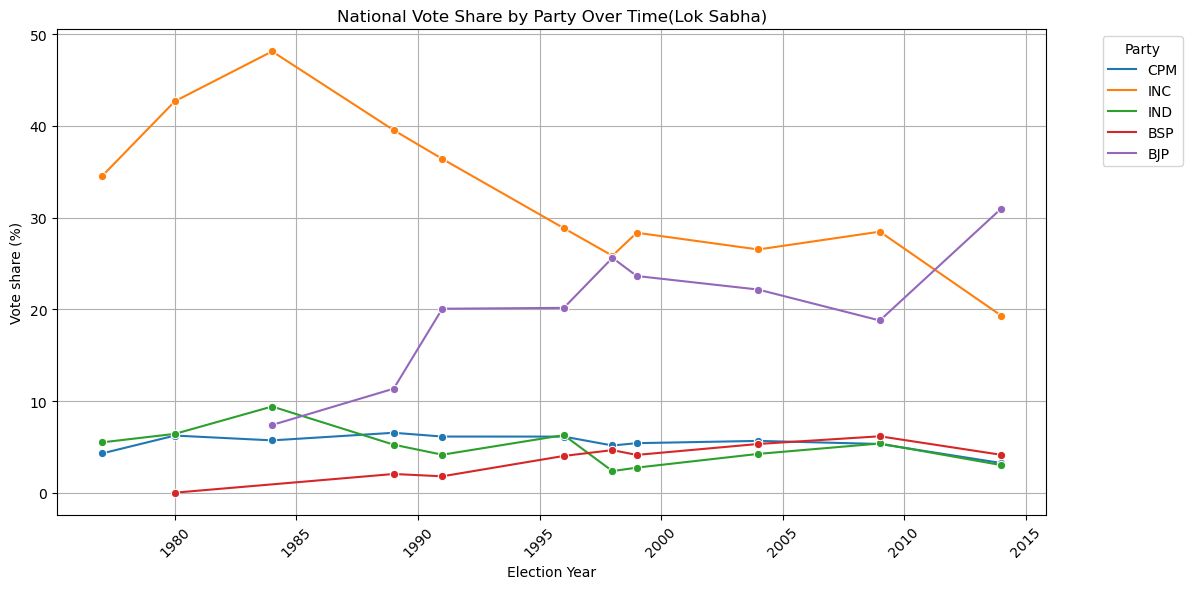

In [36]:
party_votes = (
    df_lok.groupby(['year', 'partyabbre'])['totvotpoll']
    .sum()
    .reset_index()
    .rename(columns={'totvotpoll': 'party_votes'})
)

total_votes = (
    df_lok.groupby('year')['totvotpoll']
    .sum()
    .reset_index()
    .rename(columns={'totvotpoll': 'total_votes'})
)

party_vote_share = pd.merge(party_votes, total_votes, on='year')
party_vote_share['vote_share_percent'] = (party_vote_share['party_votes']/ party_vote_share['total_votes'])*100

top_parties=(
    party_vote_share.groupby('partyabbre')['party_votes']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

top_vote_share = party_vote_share[party_vote_share['partyabbre'].isin(top_parties)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_vote_share,
    x='year',
    y='vote_share_percent',
    hue='partyabbre',
    marker='o'
)
plt.title('National Vote Share by Party Over Time(Lok Sabha)')
plt.xlabel('Election Year')
plt.ylabel('Vote share (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Party', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

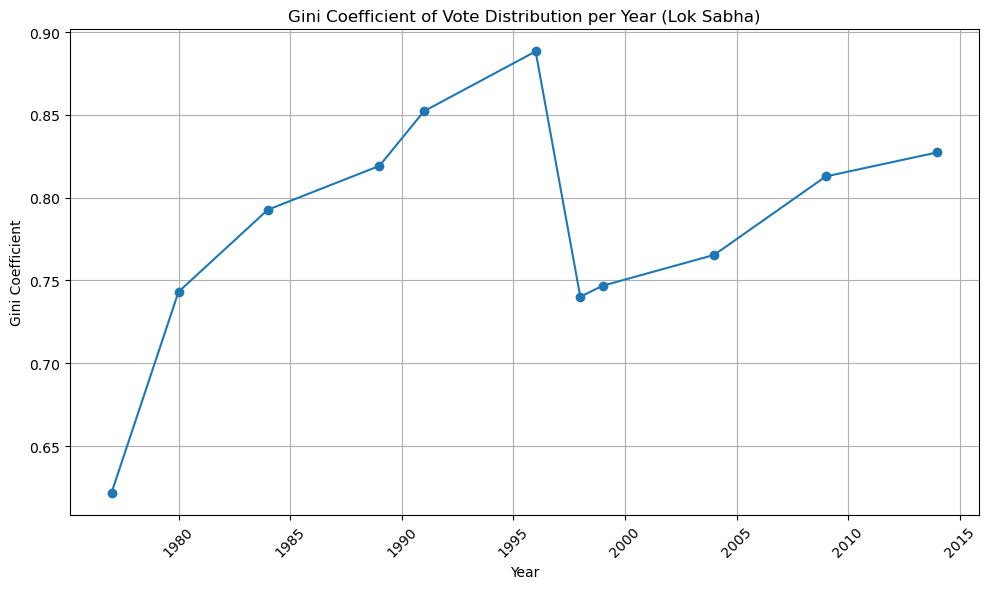

In [70]:
def gini(array):
    """Compute Gini coefficient of a numpy array"""
    array = np.sort(array)
    n = len(array)
    cumulative = np.cumsum(array)
    return (2. * np.sum(np.arange(1, n + 1) * array)) / (n * cumulative[-1]) - (n + 1) / n

# Step 2: Calculate Gini for vote distribution across all candidates
votes = df_lok['totvotpoll'].values
gini_overall = gini(votes)

# Step 3: Compute Gini for each election year
gini_yearwise = (
    df_lok.groupby('year')['totvotpoll']
    .apply(lambda x: gini(x.values))
    .reset_index(name='gini_coefficient')
)

# Step 4: Plot Gini coefficient over time
plt.figure(figsize=(10, 6))
plt.plot(gini_yearwise['year'], gini_yearwise['gini_coefficient'], marker='o', linestyle='-')
plt.title('Gini Coefficient of Vote Distribution per Year (Lok Sabha)')
plt.xlabel('Year')
plt.ylabel('Gini Coefficient')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


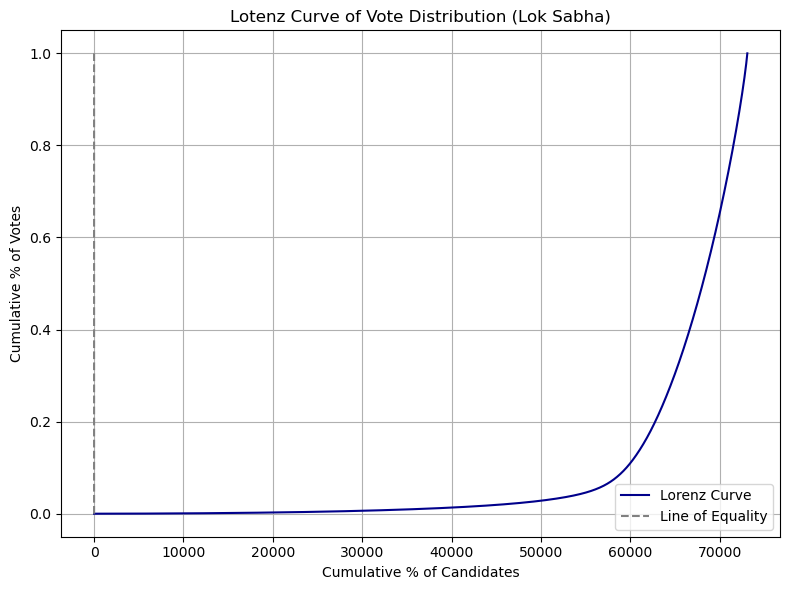

In [38]:
votes=df_lok['totvotpoll'].dropna()
votes= votes[votes>0].sort_values().values

cum_votes = np.cumsum(votes)
cum_votes_percent = cum_votes / cum_votes[-1]
cum_candidates_percent = np.arange(1,len(votes)+1/len(votes))

plt.figure(figsize=(8,6))
plt.plot(cum_candidates_percent,cum_votes_percent,label='Lorenz Curve', color='darkblue')
plt.plot([0,1],[0,1], linestyle='--',color='gray', label='Line of Equality')

plt.title('Lotenz Curve of Vote Distribution (Lok Sabha)')
plt.xlabel('Cumulative % of Candidates')
plt.ylabel('Cumulative % of Votes')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
from scipy.stats import skew, kurtosis

df_lok['totvotpoll'] = df_lok['totvotpoll'].fillna(0)
df_lok['electors']  = df_lok['electors'].replace(0,np.nan)
df_lok['vote_share_percent'] = (df_lok['totvotpoll'] / df_lok['electors'])*100

vote_share = df_lok['vote_share_percent'].dropna()
vote_share = vote_share[vote_share <=100]

vote_skewness = skew(vote_share)
vote_kurtosis = kurtosis(vote_share)

print(f"Skewness of Vote Share Distribution: {vote_skewness: .4f}")
print(f"Kurtosis of Vote Share Distribution: {vote_kurtosis: .4f}")



Skewness of Vote Share Distribution:  2.2187
Kurtosis of Vote Share Distribution:  4.0478


In [42]:
from scipy.stats import skew, kurtosis

summary = df_lok.groupby('year')['vote_share_percent'].apply(
    lambda x: pd.Series({
        'Skewness': skew(x.dropna()),
        'Kurtosis': kurtosis(x.dropna()) 
    })
).reset_index()

print(summary)

    year   level_1  vote_share_percent
0   1977  Skewness            0.869836
1   1977  Kurtosis           -0.487988
2   1980  Skewness            1.733725
3   1980  Kurtosis            1.986911
4   1984  Skewness            1.914409
5   1984  Kurtosis            2.355135
6   1989  Skewness            2.136984
7   1989  Kurtosis            3.499113
8   1991  Skewness            2.810178
9   1991  Kurtosis            7.671801
10  1996  Skewness            3.636894
11  1996  Kurtosis           13.781332
12  1998  Skewness            1.389376
13  1998  Kurtosis            0.551309
14  1999  Skewness            1.446932
15  1999  Kurtosis            0.728694
16  2004  Skewness            1.884250
17  2004  Kurtosis            2.647415
18  2009  Skewness            2.530822
19  2009  Kurtosis            5.828738
20  2014  Skewness            2.496316
21  2014  Kurtosis            5.303818


In [43]:
# party_votes
party_votes = (
    df_lok.groupby(['year', 'partyabbre'])['totvotpoll']
    .sum()
    .reset_index(name='party_votes')
)

# Step 3: Total votes cast per year
total_votes = (
    df_lok.groupby('year')['totvotpoll']
    .sum()
    .reset_index(name='total_votes')
)

# Step 4: Merge and calculate vote share
party_votes = pd.merge(party_votes, total_votes, on='year')
party_votes['vote_share_percent'] = (party_votes['party_votes'] / party_votes['total_votes']) * 100

# Step 5: Filter parties with votes in at least 3 years
party_years = party_votes['partyabbre'].value_counts()
eligible_parties = party_years[party_years >= 3].index
filtered = party_votes[party_votes['partyabbre'].isin(eligible_parties)]

# Step 6: Group by party and compute skewness & kurtosis
summary_stats = filtered.groupby('partyabbre')['vote_share_percent'].agg(
    Skewness=lambda x: x.skew(),
    Kurtosis=lambda x: x.kurtosis()
).reset_index().sort_values('Skewness', ascending=False)

# Display top skewed parties
print("📊 Most Right-Skewed Parties:")
print(summary_stats.head())

print("\n📉 Most Left-Skewed Parties:")
print(summary_stats.tail())

📊 Most Right-Skewed Parties:
    partyabbre  Skewness  Kurtosis
162     SAD(M)  2.712208  7.522732
172        SSD  2.500371  6.662787
96          JP  2.435543  5.947158
80        IUML  2.232968  4.988731
6        ABLTP  2.232646  4.987542

📉 Most Left-Skewed Parties:
    partyabbre  Skewness  Kurtosis
4         ABHS -1.680361       NaN
79        INLD -1.702090  3.206604
125        PBI -1.710534       NaN
117        MRP -1.755155  2.956283
170         SP -1.824187  4.280263


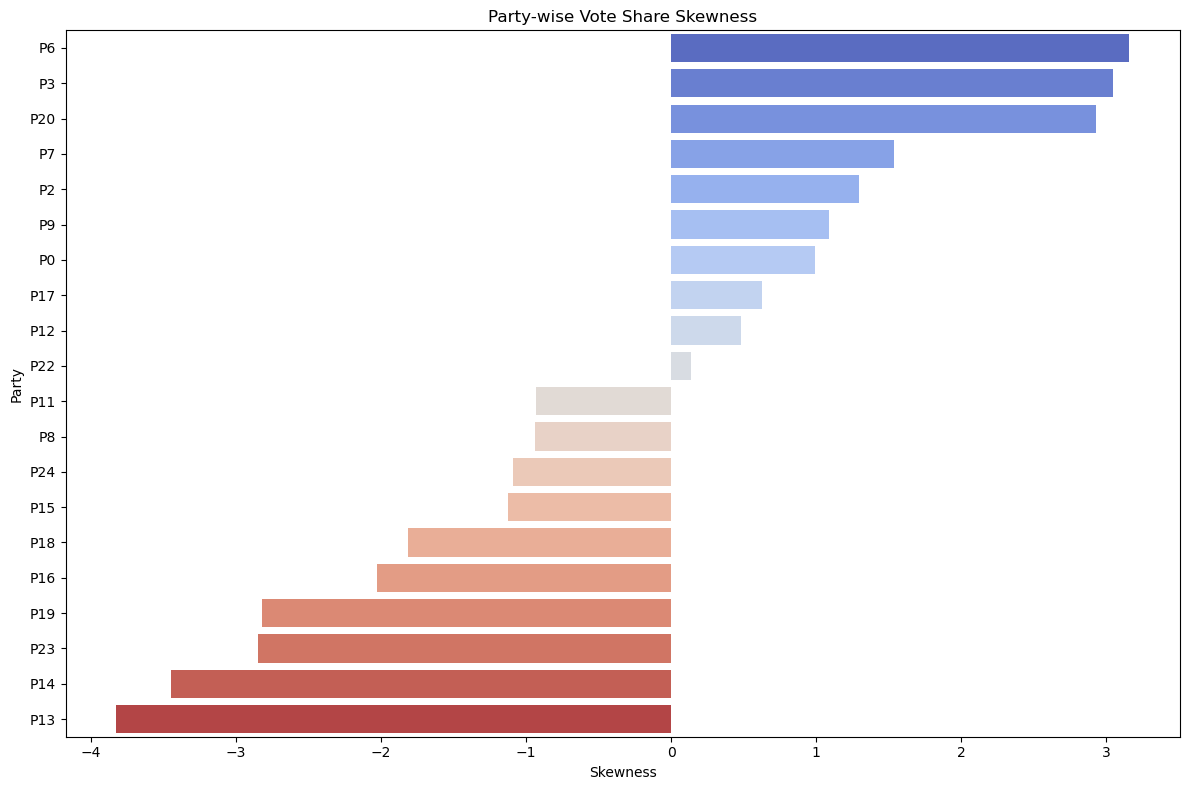

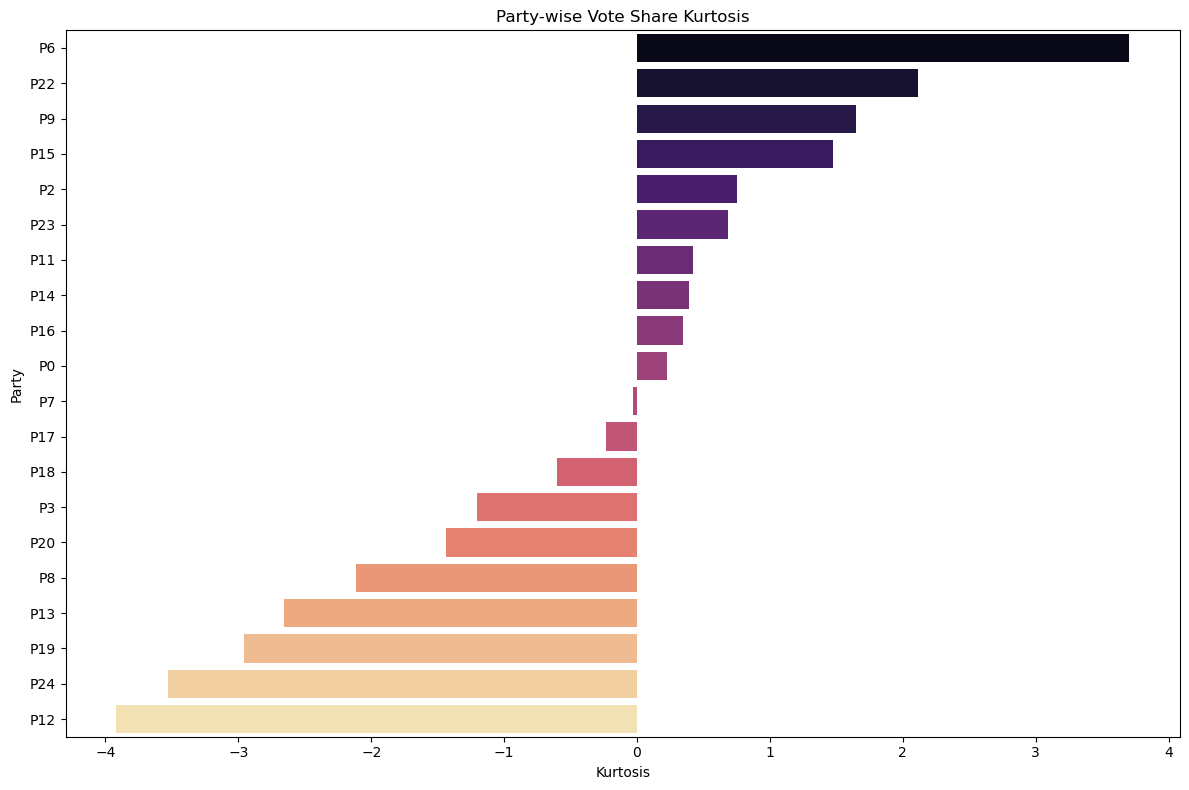

In [50]:
plot_data = pd.concat([summary_stats.head(10), summary_stats.tail(10)])

# --- Plot 1: Skewness ---
plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_data.sort_values('Skewness', ascending=False),
    x='Skewness',
    y='partyabbre',
    hue='partyabbre',
    palette='coolwarm',
    dodge=False  
)


plt.legend([],[], frameon=False)

plt.title('Party-wise Vote Share Skewness')
plt.xlabel('Skewness')
plt.ylabel('Party')
plt.tight_layout()
plt.show()

# --- Plot 2: Kurtosis 
plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_data.sort_values('Kurtosis', ascending=False),
    x='Kurtosis',
    y='partyabbre',
    hue='partyabbre',
    palette='magma',
    dodge=False
)

plt.legend([],[], frameon=False)

plt.title('Party-wise Vote Share Kurtosis')
plt.xlabel('Kurtosis')
plt.ylabel('Party')
plt.tight_layout()
plt.show()

ANOVA F-statistics: 14.8951
P-value: 2.0403e-35
 BJP's vote shares significantly differ across states.


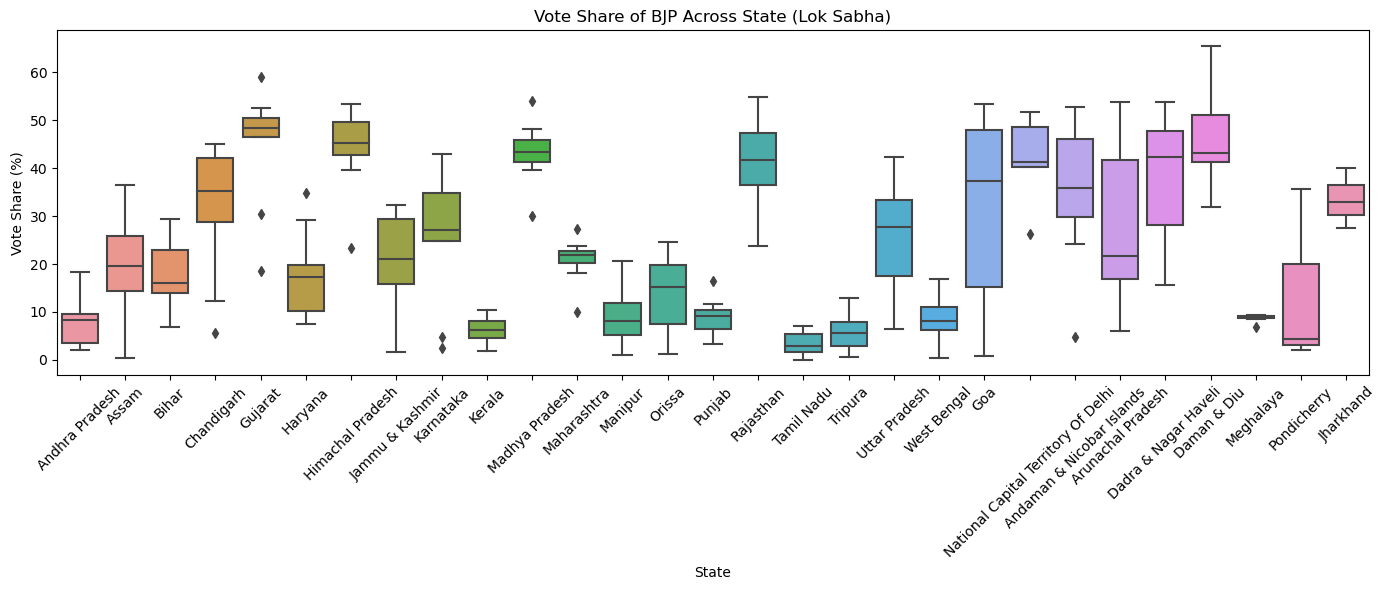

In [55]:
from scipy.stats import f_oneway

df_lok['totvotpoll'] = df_lok['totvotpoll'].fillna(0)

target_party = 'BJP'

party_votes = (
    df_lok[df_lok['partyabbre'] == target_party]
    .groupby(['year', 'st_name'])['totvotpoll']
    .sum()
    .reset_index(name='party_votes')
)

total_votes = (
    df_lok.groupby(['year', 'st_name'])['totvotpoll']
    .sum()
    .reset_index(name='total_votes')
)

merged= pd.merge(party_votes, total_votes, on=['year','st_name'])
merged['vote_share_percent']=(merged['party_votes'] / merged['total_votes']) *100

state_counts = merged['st_name'].value_counts()
eligible_states = state_counts[state_counts >= 3].index
filtered = merged[merged['st_name'].isin(eligible_states)]

grouped_data = filtered.groupby('st_name')['vote_share_percent'].apply(list)

f_stats,p_value=f_oneway(*grouped_data)

print(f"ANOVA F-statistics: {f_stats:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.5:
    print(f" {target_party}'s vote shares significantly differ across states.")
else:
    print(f" No significant difference in {target_party}'s vote share across states.")

plt.figure(figsize=(14,6))   
sns.boxplot(data=filtered, x='st_name', y='vote_share_percent')
plt.title(f'Vote Share of {target_party} Across State (Lok Sabha)')
plt.xlabel('State')
plt.ylabel('Vote Share (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ayush\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1070: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean
C:\Users\ayush\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:6999: RuntimeWarning: invalid value encountered in scalar subtract
  d = mean1 - mean2
C:\Users\ayush\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:7474: RuntimeWarning: invalid value encountered in scalar subtract
  estimate = m1-m2


T-statistics: nan
P-value: nan
 No significant difference in vote shares.


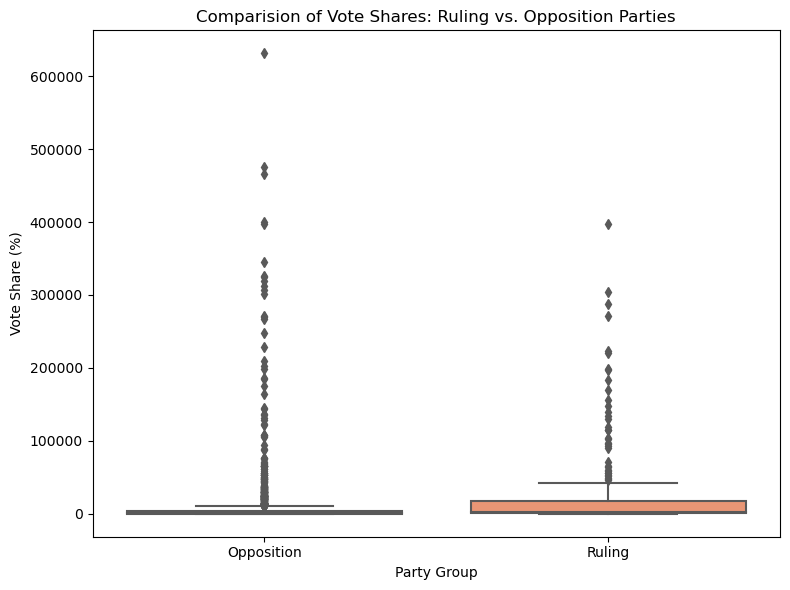

In [59]:
from scipy.stats import ttest_ind

ruling_party = 'BJP'
opposition_parties = ['INC','DMK','SP','BSP','AITC']

df_lok['totvotpoll'] = df_lok['totvotpoll'].fillna(0)

party_votes = (
    df_lok.groupby(['year', 'partyabbre'])['totvotpoll']
    .sum()
    .reset_index(name='party_votes')
)
party_votes = pd.merge(party_votes, total_votes, on='year')
party_votes['vote_share_percent'] = (party_votes['party_votes'] / party_votes['total_votes']) *100

party_votes['group'] = party_votes['partyabbre'].apply(
    lambda x: 'Ruling' if x == ruling_party else ('Opposition' if x in opposition_parties else 'Other')
)

filtered = party_votes[party_votes['group'].isin(['Ruling','Opposition'])]

ruling_shares = filtered[filtered['group'] == 'Ruling']['vote_share_percent']
opposition_shares = filtered[filtered['group'] == 'Opposition']['vote_share_percent']

t_stats,p_value=ttest_ind(ruling_shares, opposition_shares, equal_var=False)

print(f"T-statistics: {t_stats:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.5:
    print("Significant difference in ECI-style vote shares between ruling and opposition parties.")
else:
    print(" No significant difference in vote shares.")

plt.figure(figsize=(8,6))   
sns.boxplot(data=filtered, x='group', y='vote_share_percent',palette='Set2')
plt.title('Comparision of Vote Shares: Ruling vs. Opposition Parties')
plt.xlabel('Party Group')
plt.ylabel('Vote Share (%)')
plt.tight_layout()
plt.show()

T-statistic: 2.9276
P-value: 7.4741e-03
✅ Significant difference in ECI-style vote shares between ruling and opposition parties.


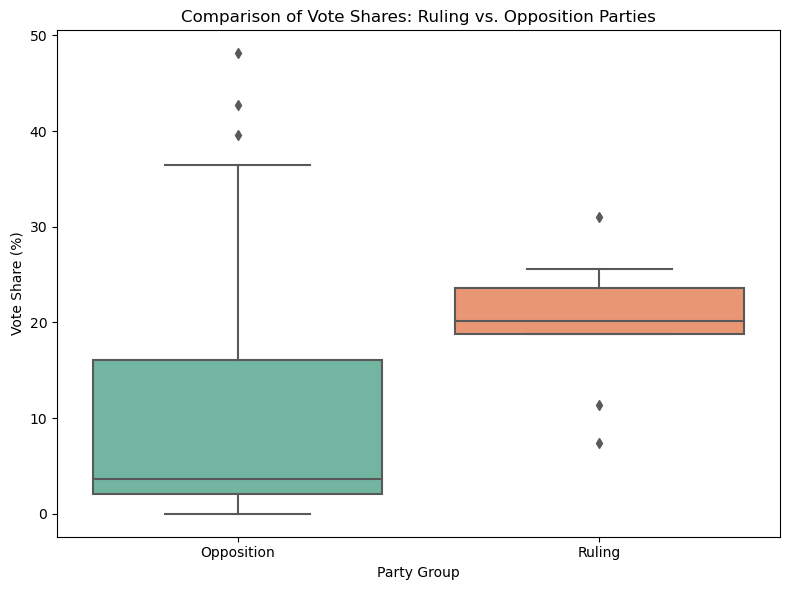

In [64]:
from scipy.stats import ttest_ind

# Step 1: Define ruling and opposition parties
ruling_party = 'BJP'
opposition_parties = ['INC', 'DMK', 'SP', 'BSP', 'AITC'] # Add more if needed

# Step 2:
df_lok['totvotpoll'] = df_lok['totvotpoll'].fillna(0)

# Step 3: Total votes for each party per year
party_votes = (
    df_lok.groupby(['year', 'partyabbre'])['totvotpoll']
    .sum()
    .reset_index(name='party_votes')
)

# Step 4: Total national votes per year
total_votes = (
    df_lok.groupby('year')['totvotpoll']
    .sum()
    .reset_index(name='total_votes')
)

# Step 5: Merge to compute ECI-style vote share
party_votes = pd.merge(party_votes, total_votes, on='year')
party_votes['vote_share_percent'] = (party_votes['party_votes'] / party_votes['total_votes']) * 100

# Step 6: Create ruling vs opposition group column
party_votes['group'] = party_votes['partyabbre'].apply(
    lambda x: 'Ruling' if x == ruling_party else ('Opposition' if x in opposition_parties else 'Other')
)

# Step 7: Filter to just ruling vs opposition
filtered = party_votes[party_votes['group'].isin(['Ruling', 'Opposition'])]

# Step 8: Prepare data for t-test
ruling_shares = filtered[filtered['group'] == 'Ruling']['vote_share_percent']
opposition_shares = filtered[filtered['group'] == 'Opposition']['vote_share_percent']

# Step 9: Run t-test
t_stat, p_value = ttest_ind(ruling_shares, opposition_shares, equal_var=False)

# Step 10: Display result
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print(f"✅ Significant difference in ECI-style vote shares between ruling and opposition parties.")
else:
    print(f"❌ No significant difference in vote shares.")

# Step 11: Boxplot visualization
plt.figure(figsize=(8, 6))
sns.boxplot(data=filtered, x='group', y='vote_share_percent', palette='Set2')
plt.title('Comparison of Vote Shares: Ruling vs. Opposition Parties')
plt.ylabel('Vote Share (%)')
plt.xlabel('Party Group')
plt.tight_layout()
plt.show()

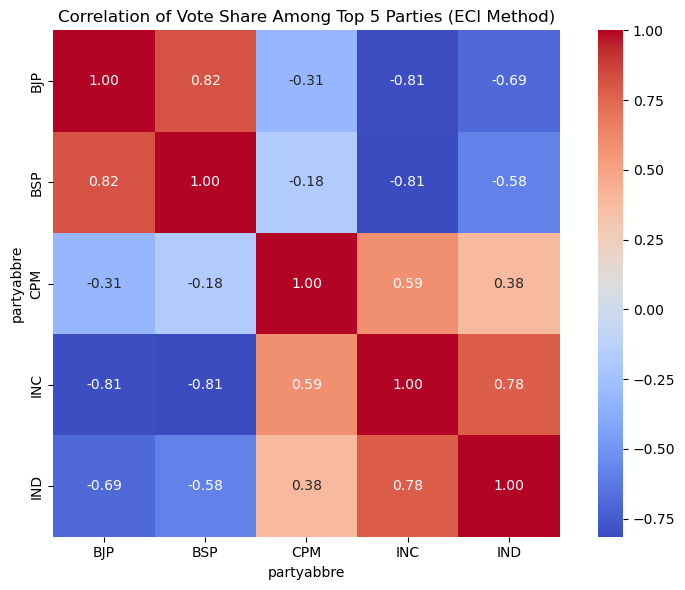

In [65]:
party_votes = (
    df_lok.groupby(['year', 'partyabbre'])['totvotpoll']
    .sum()
    .reset_index(name='party_votes')
)

# Step 2: Total national votes per year
total_votes = (
    df_lok.groupby('year')['totvotpoll']
    .sum()
    .reset_index(name='total_votes')
)

# Step 3: Merge and calculate ECI-style vote share
vote_share_df = pd.merge(party_votes, total_votes, on='year')
vote_share_df['vote_share_percent'] = (vote_share_df['party_votes'] / vote_share_df['total_votes']) * 100

# Step 4: Get top 5 parties by total votes across all years
top_5_parties = (
    vote_share_df.groupby('partyabbre')['party_votes']
    .sum()
    .nlargest(5)
    .index
)

# Step 5: Filter to top 5 parties only
top_5_df = vote_share_df[vote_share_df['partyabbre'].isin(top_5_parties)]

# Step 6: Pivot for correlation matrix (years as rows, parties as columns)
pivot_df = top_5_df.pivot_table(index='year', columns='partyabbre', values='vote_share_percent').fillna(0)

# Step 7: Compute correlation matrix
correlation_matrix = pivot_df.corr()

# Step 8: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation of Vote Share Among Top 5 Parties (ECI Method)")
plt.tight_layout()
plt.show()

In [66]:
# Total votes per party per year
party_votes = (
    df_lok.groupby(['year', 'partyabbre'])['totvotpoll']
    .sum()
    .reset_index(name='party_votes')
)

# Total national votes per year
total_votes = (
    df_lok.groupby('year')['totvotpoll']
    .sum()
    .reset_index(name='total_votes')
)

# Merge to compute vote share
vote_share_df = pd.merge(party_votes, total_votes, on='year')
vote_share_df['vote_share_percent'] = (vote_share_df['party_votes'] / vote_share_df['total_votes']) * 100

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

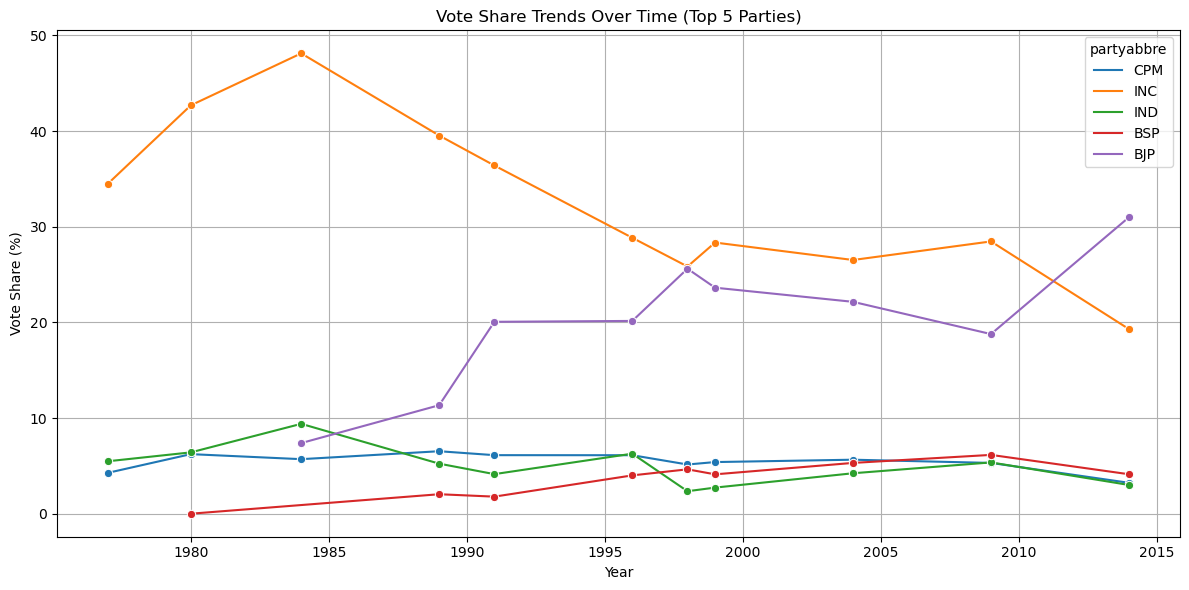

In [67]:
# Identify top 5 parties by overall votes
top_5 = (
    vote_share_df.groupby('partyabbre')['party_votes']
    .sum()
    .nlargest(5)
    .index
)

# Filter for top 5
top_df = vote_share_df[vote_share_df['partyabbre'].isin(top_5)]

# line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=top_df, x='year', y='vote_share_percent', hue='partyabbre', marker='o')
plt.title('Vote Share Trends Over Time (Top 5 Parties)')
plt.xlabel('Year')
plt.ylabel('Vote Share (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


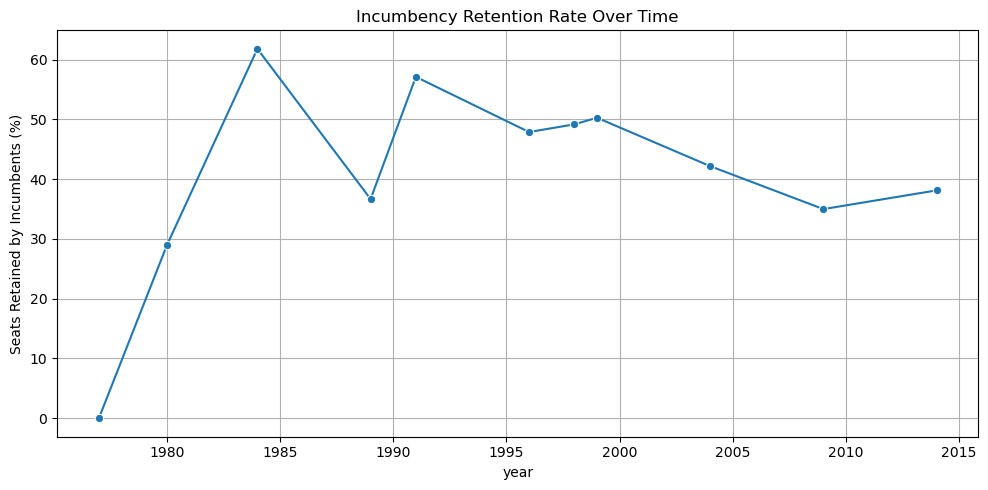

In [68]:
# Rank candidates per seat
df_lok['rank'] = df_lok.groupby(['year', 'st_name', 'pc_no'])['totvotpoll'].rank(method='first', ascending=False)
winners = df_lok[df_lok['rank'] == 1].copy()

# Sort by year and match winners in the next cycle
winners.sort_values(by=['st_name', 'pc_no', 'year'], inplace=True)
winners['prev_party'] = winners.groupby(['st_name', 'pc_no'])['partyabbre'].shift(1)
winners['retained'] = (winners['partyabbre'] == winners['prev_party'])

# Calculate % of seats retained each year
incumbency = winners.groupby('year')['retained'].mean().reset_index()
incumbency['retained'] = incumbency['retained'] * 100

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=incumbency, x='year', y='retained', marker='o')
plt.title('Incumbency Retention Rate Over Time')
plt.ylabel('Seats Retained by Incumbents (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

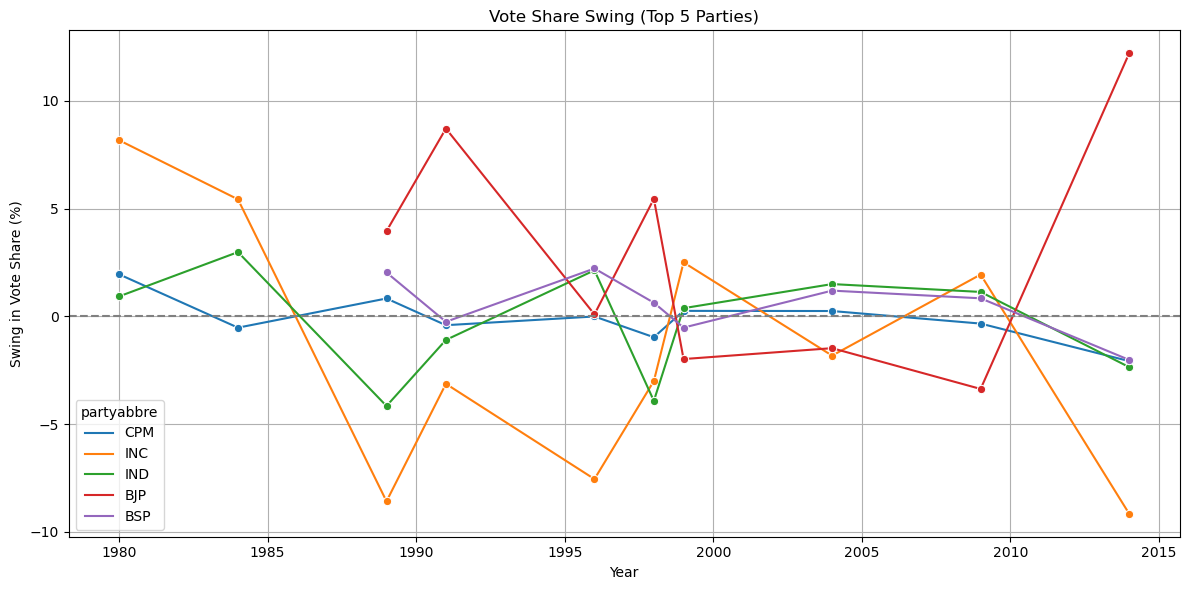

In [69]:
# Focus on top parties only
swing_df = vote_share_df[vote_share_df['partyabbre'].isin(top_5)].copy()

# Calculate year-over-year change (swing)
swing_df['prev_share'] = swing_df.groupby('partyabbre')['vote_share_percent'].shift(1)
swing_df['swing'] = swing_df['vote_share_percent'] - swing_df['prev_share']

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=swing_df.dropna(), x='year', y='swing', hue='partyabbre', marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Vote Share Swing (Top 5 Parties)')
plt.xlabel('Year')
plt.ylabel('Swing in Vote Share (%)')
plt.grid(True)
plt.tight_layout()
plt.show()